### Домашняя работа

**Задача высокого уровня** В реализацию функции `gradient` добавьте параметр $\lambda$, чтобы получить регуляризованный градиентный спуск

Формула поменяется следующим образом:
$$
\left\{
\begin{array}{cc}
\frac{\partial L}{\partial w_0} = \frac{2}{n}\cdot(-1)\cdot \sum_{i=1}^{n} (1\cdot \left(y_i - \sum_{j=1}^{m}w_jx_j^i\right) + \lambda\cdot 2\cdot w_0)&\\
\frac{\partial L}{\partial w_k} = \frac{2}{n}\cdot(-1)\cdot \sum_{i=1}^{n} (x_k^i \cdot\left(y_i - \sum_{j=1}^{m}w_jx_j^i\right) + \lambda\cdot 2\cdot w_k)& k\neq 0 \\
\end{array}
\right.
$$

In [10]:
import numpy as np
import pandas as pd

data = pd.read_csv('non_linear.csv', sep=',')
data = data[(data.x_train > 1) & (data.x_train < 5)].copy()
data.head()

,x_train,y_train
5,1.182421,1.860341
6,1.251605,1.878928
7,1.270474,2.430015
8,1.402553,2.327856
9,1.427711,2.203649


In [25]:
from scipy.spatial import distance
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def gradient(X, y, w) -> np.array:
    # количество обучающих примеров в выборке
    n = X.shape[0]
    # считаем прогноз
    y_hat = X.dot(w)
    # вычисляем ошибку прогноза
    error = y - y_hat
    # дальше pointwise перемножение - умножаем каждую из координат на ошибку
    grad = np.multiply(X, error.reshape(-1, 1)).sum(axis=0)*(-1.0)*2.0 / n
    return grad, error

In [42]:
def eval_w_next(X, y, eta, w_current, lambda_reg=0.01): #добавляем атрибут - силу регуляции
    # вычисляем градиент
    grad, error = gradient(X, y, w_current)
    # делаем шаг градиентного спуска
    w_next = w_current - eta*(grad + 2 * lambda_reg * w_current) #добавляем вычитание регуляци из градиента
    # проверяем условие сходимости
    weight_evolution = distance.euclidean(w_current, w_next)
    return (w_next, weight_evolution, grad)

In [43]:
def gradient_descent(X: np.array, y: np.array, eta=0.01, epsilon=0.001, lambda_reg=0.01) -> np.array:
    m = X.shape[1] # количество фичей
    # инициализируем рандомом веса
    w = np.random.random(m)
    y = y.flatten()  # преобразуем y в 1D массив
    w_next, weight_evolution, grad = eval_w_next(X, y, eta, w)
    step = 0
    # повторяем до сходимости вектора весов
    while weight_evolution > epsilon:
        w = w_next
        w_next, weight_evolution, grad = eval_w_next(X, y, eta, w)
        step += 1
        if step % 100 ==0:
            print("step %s |w-w_next|=%.5f, grad=%s" % (step, weight_evolution, grad))
    return w_next

In [44]:
# трансформируем плоский массив X в вектор-столбец
X = data['x_train'].values.reshape(-1, 1)
n = X.shape[0]
# добавляем тривиальный признак w_0, столбец из единиц. См. прошлый урок, почему так
X = np.hstack([
    np.ones(n).reshape(-1,1),
    X
])
w = gradient_descent(X, data['y_train'].values.reshape(-1, 1), eta=0.008, lambda_reg=0.01)

step 100 |w-w_next|=0.00382, grad=[-0.47949537  0.1348499 ]
step 200 |w-w_next|=0.00310, grad=[-0.39879389  0.11153685]
step 300 |w-w_next|=0.00251, grad=[-0.33343882  0.09265706]
step 400 |w-w_next|=0.00203, grad=[-0.28051183  0.07736751]
step 500 |w-w_next|=0.00164, grad=[-0.23764957  0.06498546]
step 600 |w-w_next|=0.00133, grad=[-0.20293811  0.05495801]
step 700 |w-w_next|=0.00108, grad=[-0.17482747  0.0468374 ]


In [ ]:
#У нас произошло несколько сотен итераций, на каждой итерации мы:

#вычисляем вектор весов
#смотрим расстояние между новым вектором весов и векторов весов с предыдущего шага
#если изменения в векторе весов небольшие (скажем, четвёртый знак поcле запятой) - останавливаем итерации

In [45]:
#Применяем модель
support = np.linspace(X.min(), X.max(), num=100)
# делаем предикт - считаем предсказания модели в каждой точке обучающей выборки в виде y=X*w
y_hat = np.hstack([
    np.ones(support.size).reshape(-1, 1),
    support.reshape(-1, 1)
]).dot(w.T)

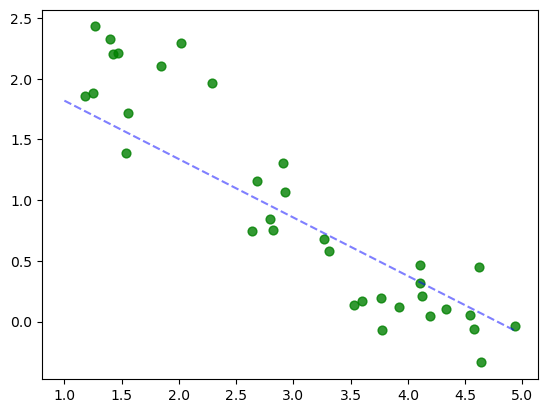

In [46]:
# строим график
plt.plot(support, y_hat, 'b--', alpha=0.5, label='manifold')
plt.scatter(data['x_train'], data['y_train'],  s=40, c='g', marker='o', alpha=0.8, label='data')
plt.show()
#вывод: получается с регуляризацией модель обучилась чуть быстрее, наблюдается параметр w-w_next ближе к цели остановки epsilon, чем без регуляризации

В этом модуле мы узнали, как  обучать линейную регрессию, не "упираясь" в аппаратные ресурсы: использовать градиентный спуск.
Мы узнали, как детектировать переобучение модели и закрепили свои знания на примере полиномиальной регрессии и выяснили, как увеличить качество решения с помощью механизма регуляризации. Познакомились с двумя видами регуляризации -  Ridge и Lasso.